# Principal Component Analysis (PCA)

В этом ноутбуке посмотрим:
1. Зачем уменьшать размерность
2. Готовим данные и зачем нужен `StandardScaler`
3. PCA: превращаем признаки в главные компоненты
4. `explained_variance_ratio_` — что это
5. Как выбрать количество компонент

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

plt.rcParams['figure.figsize'] = (7, 5)
plt.rcParams['axes.grid'] = True

## 1. Зачем уменьшать размерность

Когда признаков много:
- сложно **визуализировать** данные (мы видим максимум 2–3 измерения);
- признаки часто **скоррелированы** → информация дублируется;
- модели медленнее обучаются и легче переобучаются (*проклятие размерности*).

**PCA** ищет новые оси (главные компоненты), вдоль которых данные больше всего «разбросаны». Оставляя только первые компоненты, мы теряем мало информации, но получаем компактное представление.

## 2. Данные и StandardScaler

Возьмём датасет Iris — 4 признака, 3 класса.

In [ ]:
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = iris.target

X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [ ]:
X.describe().round(2)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20
std,0.83,0.44,1.77,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


### Данные до PCA

Посмотрим на пары признаков — уже видно, что часть информации дублируется.

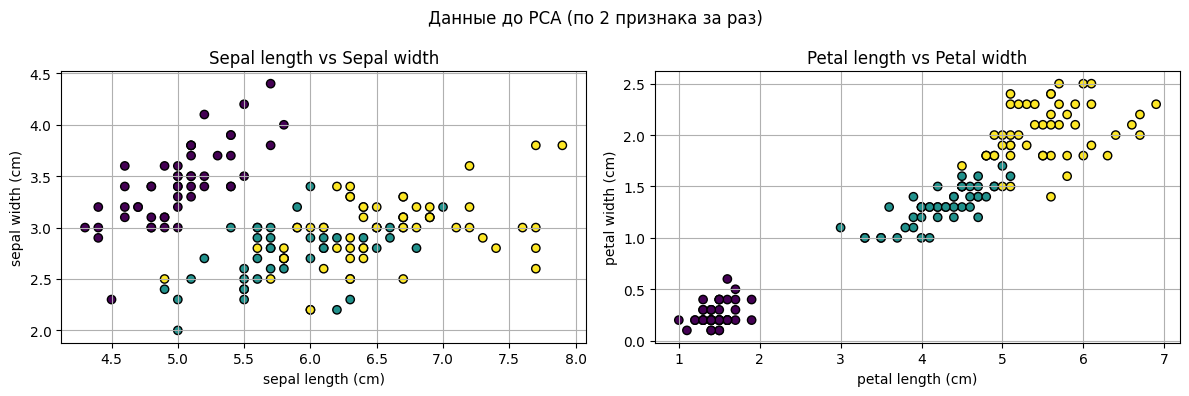

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(X.iloc[:, 0], X.iloc[:, 1], c=y, cmap='viridis', edgecolor='k')
axes[0].set_xlabel(iris.feature_names[0])
axes[0].set_ylabel(iris.feature_names[1])
axes[0].set_title('Sepal length vs Sepal width')

axes[1].scatter(X.iloc[:, 2], X.iloc[:, 3], c=y, cmap='viridis', edgecolor='k')
axes[1].set_xlabel(iris.feature_names[2])
axes[1].set_ylabel(iris.feature_names[3])
axes[1].set_title('Petal length vs Petal width')

plt.suptitle('Данные до PCA (по 2 признака за раз)')
plt.tight_layout()
plt.show()

### Почему перед PCA нужен StandardScaler

PCA максимизирует **дисперсию**. Если один признак измеряется в сантиметрах, а другой — в килограммах, признак с большими числами «перетянет» все компоненты на себя. Поэтому признаки приводят к одному масштабу: среднее = 0, стандартное отклонение = 1.

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Среднее после масштабирования:', X_scaled.mean(axis=0).round(2))
print('Std после масштабирования:   ', X_scaled.std(axis=0).round(2))

Среднее после масштабирования: [-0. -0. -0. -0.]
Std после масштабирования:    [1. 1. 1. 1.]


## 3. Применяем PCA

Сначала возьмём 2 компоненты, чтобы получилось нарисовать.

In [ ]:
pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X_scaled)

print('Форма исходных данных :', X_scaled.shape)
print('Форма после PCA       :', X_pca.shape)

Форма исходных данных : (150, 4)
Форма после PCA       : (150, 2)


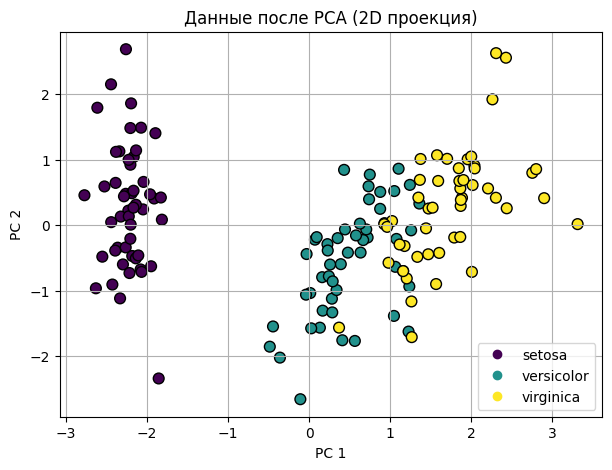

In [ ]:
plt.figure(figsize=(7, 5))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', edgecolor='k', s=60)
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.title('Данные после PCA (2D проекция)')
plt.legend(handles=scatter.legend_elements()[0], labels=list(iris.target_names))
plt.show()

Из 4 признаков получили 2 — и классы хорошо разделяются на одной картинке.

Главные компоненты — это **линейные комбинации** исходных признаков:

In [ ]:
components = pd.DataFrame(
    pca_2d.components_,
    columns=iris.feature_names,
    index=['PC1', 'PC2']
)
components.round(3)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
PC1,0.521,-0.269,0.580,0.565
PC2,0.377,0.923,0.024,0.067


## 4. `explained_variance_ratio_`

Это доля дисперсии (= информации) исходных данных, которую «забирает» каждая компонента. Сумма всех компонент = 1.

In [ ]:
pca_full = PCA().fit(X_scaled)
evr = pca_full.explained_variance_ratio_

for i, v in enumerate(evr, 1):
    print(f'PC{i}: {v:.3f}  ({v*100:.1f} %)')
print(f'Сумма: {evr.sum():.3f}')

PC1: 0.730  (73.0 %)
PC2: 0.229  (22.9 %)
PC3: 0.037  (3.7 %)
PC4: 0.005  (0.5 %)
Сумма: 1.000


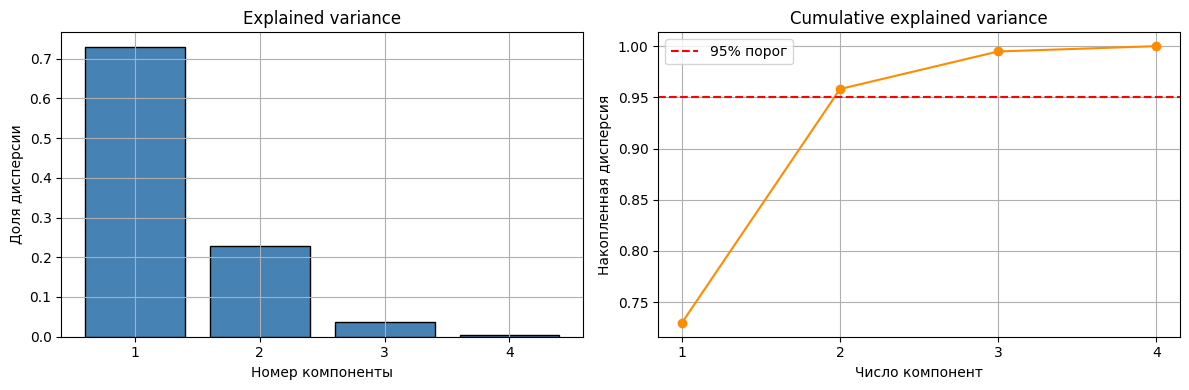

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(1, len(evr)+1), evr, color='steelblue', edgecolor='k')
axes[0].set_xticks(range(1, len(evr)+1))
axes[0].set_xlabel('Номер компоненты')
axes[0].set_ylabel('Доля дисперсии')
axes[0].set_title('Explained variance')

cum = np.cumsum(evr)
axes[1].plot(range(1, len(cum)+1), cum, marker='o', color='darkorange')
axes[1].axhline(0.95, color='red', linestyle='--', label='95% порог')
axes[1].set_xticks(range(1, len(cum)+1))
axes[1].set_xlabel('Число компонент')
axes[1].set_ylabel('Накопленная дисперсия')
axes[1].set_title('Cumulative explained variance')
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Как выбрать количество компонент

Два простых подхода:

**(a) По порогу дисперсии** — например, оставить столько компонент, чтобы суммарно было ≥ 95% информации. Можно передать долю прямо в PCA:

In [ ]:
pca_95 = PCA(n_components=0.95).fit(X_scaled)
print('Чтобы сохранить >= 95% дисперсии, нужно компонент:', pca_95.n_components_)

Чтобы сохранить >= 95% дисперсии, нужно компонент: 2


**(b) По «локтю»** на графике cumulative explained variance — точка, после которой кривая выходит на плато. Для Iris это 2 компоненты (≈ 96%).

#**Общий итог:**

- PCA уменьшает размерность, оставляя максимум дисперсии.
- Перед PCA почти всегда применяют `StandardScaler`.
- `explained_variance_ratio_` показывает, сколько информации сохраняет каждая компонента.
- Число компонент выбирают по порогу (например 95%) или по «локтю» на графике накопленной дисперсии.